# CorpPolicyLM — Assignment 1A: Continual Pre-Training + QLoRA Instruction Fine-Tuning

**Domain:** HR Policy & Corporate Documents (Enterprise Variant 1 — Domain Q&A Assistant)
**Model:** `TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T` (HR row, T4 — Choice 2) **GPU used:** BITS remote-lab NVIDIA L40S (48 GB, native bf16); the same code runs on a Colab T4 (16 GB)
**Pipeline:** raw policy PDFs → cleaned corpus → packed tokens → CPT → perplexity & forgetting → instruction dataset → QLoRA (Adapter B) → evaluation

| Part | Step | Marks |
|---|---|---|
| A | 1 Data collection, extraction & cleaning | 2 |
| A | 2 Tokenisation & packed dataset | 2 |
| A | 3 Model loading & architecture inspection | 2 |
| A | 4 CPT training loop & loss analysis | 2 |
| A | 5 Perplexity & catastrophic forgetting | 2 |
| B | B1 Instruction dataset · B2 QLoRA (Adapter B) · B3 Evaluation | 2 + 2 + 1 |

### Why TinyLlama-1.1B?
* It is the HR-Policy model listed for a T4 GPU, and at 1.1 B parameters a *full-parameter* CPT fits in 16 GB with gradient checkpointing + 8-bit paged AdamW.
* It is a LLaMA-architecture model, so its attention projections are literally named `q_proj`, `k_proj`, `v_proj`, `o_proj` — the target modules in the QLoRA adapter table map one-to-one.
* It was pre-trained on ~3 T tokens of general web/code text, so it knows general English but has seen little Indian HR-policy language (band levels, EL/CL/SL, notice periods, POSH/ICC, vigil mechanisms) — a realistic domain gap for CPT to close.
* The *base* checkpoint (not the chat model) is used for CPT, and its tokenizer is used for every step — no tokenizer swapping.

All logic lives in the `src/` package (one module per step); this notebook calls it, shows the outputs, and records inferences.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/CorpPolicyLM"
else:
    PROJECT_DIR = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
print("Project:", PROJECT_DIR)

Project: /home/jovyan/datavol-1/CorpPolicyLM


In [2]:
# Install pinned requirements. In a headless run (run_notebook.sh) they are installed
# *before* the kernel starts: upgrading numpy/pandas inside a running kernel leaves
# half-old, half-new binaries loaded ("Cannot convert numpy.ndarray to numpy.ndarray").
import importlib.util
needed = ["transformers", "trl", "peft", "bitsandbytes", "accelerate", "datasets",
          "pypdf", "langdetect", "pyarrow", "matplotlib"]
missing = [m for m in needed if importlib.util.find_spec(m) is None]
if os.environ.get("NOTEBOOK_HEADLESS") == "1":
    print("Headless run: requirements were installed by run_notebook.sh before this kernel started.")
elif not missing:
    print("All required packages are already installed in this kernel - nothing to install.")
else:
    print("Installing missing packages:", missing, "- restart the kernel afterwards, then Run All again.")
    get_ipython().run_line_magic("pip", "install -q -r requirements.txt")

Installing missing packages: ['pypdf'] - restart the kernel afterwards, then Run All again.
Note: you may need to restart the kernel to use updated packages.


> **First run on a fresh Colab runtime:** the cell above upgrades `transformers`/`trl`/`peft`. Use *Runtime → Restart session* once, then run the setup cell again and continue from here.

In [3]:
import json, torch, pandas as pd
from IPython.display import display, Image, Markdown
pd.set_option("display.max_colwidth", 200)
from src import config
config.ensure_dirs()
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB | compute capability {p.major}.{p.minor}")
print("Model:", config.MODEL_ID, "| block size:", config.BLOCK_SIZE)

torch 2.5.1+cu124 | CUDA: True
GPU: NVIDIA L40S | 47.8 GB | compute capability 8.9
Model: TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T | block size: 2048


# PART A — Continual Pre-Training (CPT)

## Step 1 — Data collection, extraction & cleaning  [2 marks]

### 1a. Data collection
The starting corpus was 4 MyGov (Govt. of India) HR policies — *Leave, Attendance & Work Protocols, Exit, Domestic Travel* (~4.3 K words ≈ 6 K tokens). That is only 2–3 packed 2048-token sequences: far too little for a meaningful loss curve or a 10 % held-out set. It was expanded with public HR / corporate-policy PDFs listed in `data/sources.csv`:

| Category | Examples |
|---|---|
| Government HR rules | CCS (Leave) Rules 1972, CCS (Conduct) Rules 1964, MyGov laptop / talent-development / internship policies |
| Organisation HR manuals | IIM Udaipur (permanent, contractual & faculty), IIM Raipur, IIHMR, AICB, IILM, Indus & DAV universities, INOXCVA, MSRLS |
| Leave rules | NIT Tiruchirappalli, Shiv Nadar University |
| POSH policies | BASF, 3M, Sony Pictures Networks, Bajaj Broking, JioStar, Tata Elxsi, BPTP, Sudarshan, Mafatlal |
| Code of conduct / anti-bribery / human rights | Bharat Forge, Accelya, Niramai, EID Parry, Aurobindo, Oil India, Infosys, Home First |
| Whistle-blower / vigil mechanism | AU Bank, BEML, IKS Health, Astral, GHL, Khanna Paper, DreamFolks, GrowXCD |

One source (`mygov_travel_policy_dup.pdf`) is deliberately the same file as `travel_policy.pdf` to verify that the deduplication stage works. `download_corpus` is idempotent: files already present are skipped, so re-running only fetches what is missing. It sends browser-like headers (several institutional sites reject scripted user agents with 403/404), retries transient errors, and verifies TLS with the `certifi` CA bundle. URLs that are permanently dead are logged in `download_report.csv` and never stop the run.

In [4]:
from src.download_corpus import download_corpus
dl = pd.DataFrame(download_corpus())
display(dl[["file_name", "category", "status", "bytes"]])
print(dl["status"].str.split(":").str[0].value_counts().to_string())

mygov_laptop_policy.pdf                       already_present
mygov_talent_development_policy.pdf           already_present
mygov_internship_program.pdf                  already_present
mygov_travel_policy_dup.pdf                   already_present
ccs_leave_rules_1972.pdf                      already_present
ccs_conduct_rules_1964.pdf                    already_present
msrls_hr_manual.pdf                           already_present
indus_university_hr_manual.pdf                already_present
iilm_university_hr_policy_manual.pdf          failed: HTTPError: HTTP Error 404: Not Found
dav_university_hr_employee_manual.pdf         already_present
inoxcva_hr_manual_2025.pdf                    failed: URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unabl
inoxcva_hr_manual.pdf                         failed: URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unabl
iimu_hr_manual_permanent.pdf                  failed: HTTPErr

,file_name,category,status,bytes
0,mygov_laptop_policy.pdf,it_asset,already_present,564812
1,mygov_talent_development_policy.pdf,learning,already_present,123141
2,mygov_internship_program.pdf,internship,already_present,325514
3,mygov_travel_policy_dup.pdf,travel,already_present,134384
4,ccs_leave_rules_1972.pdf,leave_rules,already_present,1943246
5,ccs_conduct_rules_1964.pdf,conduct_rules,already_present,587947
6,msrls_hr_manual.pdf,hr_manual,already_present,2853571
7,indus_university_hr_manual.pdf,hr_manual,already_present,2360506
8,iilm_university_hr_policy_manual.pdf,hr_manual,failed: HTTPError: HTTP Error 404: Not Found,0
9,dav_university_hr_employee_manual.pdf,hr_manual,already_present,533199


status
already_present    30
failed             17


### 1b. Page-by-page extraction (`src/extract.py`, pypdf)
Each PDF is read page by page; every page is written with a `--- PAGE n ---` marker so the cleaner can detect running headers/footers. Pages with no extractable text (scanned images) are counted.

In [5]:
from src.extract import extract_corpus
ext = pd.DataFrame(extract_corpus(config.RAW_PDF_DIR, config.EXTRACTED_TEXT_DIR,
                                  config.REPORT_DIR / "extraction_report.csv"))
display(ext.sort_values("total_pages", ascending=False))
print(f"{len(ext)} PDFs | {ext.total_pages.sum()} pages | {ext.empty_pages.sum()} pages without text | "
      f"{ext.characters_extracted.sum():,} characters")

Saved 3m_posh_policy.txt: 7 pages
Saved Leave_Policy.txt: 5 pages
Saved accelya_code_of_conduct.txt: 21 pages
Saved aicb_hr_manual.txt: 11 pages
Saved astral_whistle_blower_policy.txt: 6 pages
Saved attendance_policy.txt: 2 pages
Saved aubank_whistle_blower_policy.txt: 4 pages
Saved aurobindo_human_rights_policy.txt: 4 pages
Saved bajaj_broking_posh_policy.txt: 18 pages
Saved beml_whistle_blower_policy.txt: 9 pages
Saved bptp_posh_policy.txt: 25 pages
Saved ccs_conduct_rules_1964.txt: 38 pages
Saved ccs_leave_rules_1972.txt: 73 pages
Saved dav_university_hr_employee_manual.txt: 34 pages
Saved dreamfolks_vigil_mechanism_policy.txt: 9 pages
Saved eidparry_human_rights_policy.txt: 3 pages
Saved exit_policy.txt: 8 pages
Saved ghl_vigil_mechanism_policy.txt: 7 pages
Saved growxcd_vigil_mechanism_policy.txt: 14 pages
Saved homefirst_human_rights_policy.txt: 5 pages
Saved iihmr_hr_policy_manual.txt: 33 pages
Saved iim_raipur_hr_policy_service_rules.txt: 200 pages
Saved indus_university_hr_man

,file_name,total_pages,text_pages,empty_pages,characters_extracted
21,iim_raipur_hr_policy_service_rules.pdf,200,200,0,406684
22,indus_university_hr_manual.pdf,164,164,0,283000
26,msrls_hr_manual.pdf,144,144,0,230217
12,ccs_leave_rules_1972.pdf,73,73,0,152533
11,ccs_conduct_rules_1964.pdf,38,38,0,14250
13,dav_university_hr_employee_manual.pdf,34,34,0,88938
20,iihmr_hr_policy_manual.pdf,33,33,0,72987
10,bptp_posh_policy.pdf,25,25,0,36013
2,accelya_code_of_conduct.pdf,21,21,0,46782
8,bajaj_broking_posh_policy.pdf,18,18,0,48861


34 PDFs | 902 pages | 0 pages without text | 1,657,131 characters


### 1c. Cleaning pipeline (`src/clean.py`)
| Stage | What it does | Why |
|---|---|---|
| 0 basic cleaning | NFKC normalisation, control-character removal, de-hyphenation, drop page markers / page numbers, drop lines repeated on ≥ 50 % of pages (headers, footers, document-control blocks), collapse whitespace | Boilerplate repeated on every page would be over-learned by CPT and inflates token counts |
| 1 length filter | drop documents < 100 words | near-empty extractions (scanned PDFs, cover pages) carry no language signal |
| 2 exact dedup | SHA-256 of whitespace/case-normalised text | identical files would be seen twice per epoch → memorisation |
| 3 near dedup | 5-word-shingle Jaccard ≥ 0.8 against kept docs | revised versions of the same policy (e.g. two INOXCVA manuals) are ~90 % identical |
| 4 language filter | `langdetect` (seeded) keeps `en` only | bilingual Hindi/English government PDFs would add a second language |

In [6]:
from src.clean import clean_corpus, summarize_corpus
records = clean_corpus(config.EXTRACTED_TEXT_DIR, config.DOMAIN_CORPUS_DIR, config.REPORT_DIR / "cleaning_report.csv")
summary = summarize_corpus(records)
(config.REPORT_DIR / "corpus_summary.json").write_text(json.dumps(summary, indent=2))
stages = pd.DataFrame(summary["stages"])
display(stages)
rej = pd.DataFrame(records).query("status == 'rejected'")
display(rej[["file_name", "reason", "duplicate_of", "max_similarity", "language", "word_count"]])
kept = pd.DataFrame(records).query("status == 'kept'").sort_values("max_similarity", ascending=False)
print("Most similar kept documents (5-gram Jaccard vs. any earlier kept doc) — all below the 0.8 near-dup threshold:")
display(kept[["file_name", "max_similarity", "word_count"]].head(5))

3m_posh_policy.txt: 2492 words - passes_filters (language: en)
accelya_code_of_conduct.txt: 5865 words - passes_filters (language: en)
aicb_hr_manual.txt: 2676 words - passes_filters (language: en)
astral_whistle_blower_policy.txt: 1482 words - passes_filters (language: en)
attendance_policy.txt: 614 words - passes_filters (language: en)
aubank_whistle_blower_policy.txt: 1220 words - passes_filters (language: en)
aurobindo_human_rights_policy.txt: 1315 words - passes_filters (language: en)
bajaj_broking_posh_policy.txt: 6668 words - passes_filters (language: en)
beml_whistle_blower_policy.txt: 3223 words - passes_filters (language: en)
bptp_posh_policy.txt: 5427 words - passes_filters (language: en)
ccs_conduct_rules_1964.txt: 1967 words - passes_filters (language: en)
ccs_leave_rules_1972.txt: 23118 words - passes_filters (language: en)
dav_university_hr_employee_manual.txt: 13747 words - passes_filters (language: en)
dreamfolks_vigil_mechanism_policy.txt: 2093 words - passes_filters 

,stage,documents_before,documents_after,documents_removed,characters_before,characters_after,characters_removed
0,basic_cleaning,34,34,0,1667578,1527848,139730
1,length_filter,34,34,0,1527848,1527848,0
2,deduplication,34,33,1,1527848,1521426,6422
3,near_dedup,33,33,0,1521426,1521426,0
4,english_filter,33,33,0,1521426,1521426,0


,file_name,reason,duplicate_of,max_similarity,language,word_count
33,mygov_travel_policy_dup.txt,exact_duplicate,travel_policy.txt,1.0,not_checked,1083


Most similar kept documents (5-gram Jaccard vs. any earlier kept doc) — all below the 0.8 near-dup threshold:


,file_name,max_similarity,word_count
16,ghl_vigil_mechanism_policy.txt,0.134,2047
13,dreamfolks_vigil_mechanism_policy.txt,0.132,2093
9,bptp_posh_policy.txt,0.083,5427
17,growxcd_vigil_mechanism_policy.txt,0.081,3171
8,beml_whistle_blower_policy.txt,0.071,3223


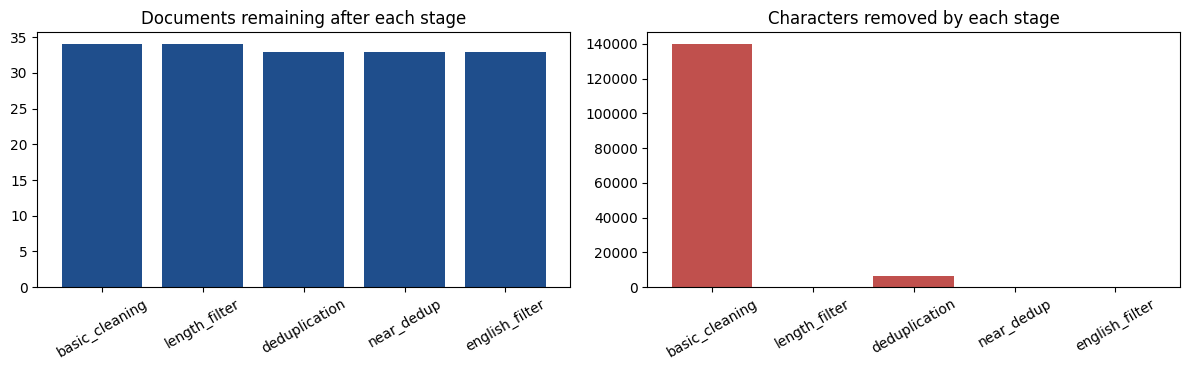

Documents: 34 → 33 | characters: 1,667,578 → 1,521,426 (−8.76%)
Greatest impact on document count : deduplication
Greatest impact on corpus size (chars): basic_cleaning
Retained words: total 241,533 | per doc min 326 / median 2047 / max 58531


In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(stages.stage, stages.documents_after, color="#1f4e8c"); ax[0].set_title("Documents remaining after each stage")
ax[1].bar(stages.stage, stages.characters_removed, color="#c0504d"); ax[1].set_title("Characters removed by each stage")
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(config.FIGURE_DIR / "cleaning_stages.png", dpi=150); plt.show()

w = summary["retained_document_words"]
biggest_docs = summary["largest_document_removal_stages"] or ["none"]
biggest_chars = summary["largest_character_removal_stages"] or ["none"]
print(f"Documents: {summary['documents_before']} → {summary['documents_after']} | characters: "
      f"{summary['characters_before']:,} → {summary['characters_after']:,} (−{summary['character_reduction_percent']}%)")
print(f"Greatest impact on document count : {', '.join(biggest_docs)}")
print(f"Greatest impact on corpus size (chars): {', '.join(biggest_chars)}")
print(f"Retained words: total {w['total']:,} | per doc min {w['minimum']} / median {w['median']} / max {w['maximum']}")

In [8]:
skipped = ext.query("total_pages == 0").file_name.tolist()
st = {r["stage"]: r for r in summary["stages"]}
print(f"* Collected {len(dl)} sources -> {int(dl.status.isin(['downloaded', 'already_present']).sum())} downloaded; "
      f"{len(ext)} PDFs with the 4 original MyGov policies; {len(skipped)} unreadable: {skipped or 'none'}")
for name in ["basic_cleaning", "length_filter", "deduplication", "near_dedup", "english_filter"]:
    r = st[name]
    print(f"* {name:<15} docs {r['documents_before']} -> {r['documents_after']} (−{r['documents_removed']}), "
          f"chars −{r['characters_removed']:,} ({100 * r['characters_removed'] / max(1, r['characters_before']):.2f}%)")
print(f"* Greatest impact — documents: {', '.join(summary['largest_document_removal_stages']) or 'none'}; "
      f"characters: {', '.join(summary['largest_character_removal_stages']) or 'none'}")

* Collected 47 sources -> 30 downloaded; 34 PDFs with the 4 original MyGov policies; 0 unreadable: none
* basic_cleaning  docs 34 -> 34 (−0), chars −139,730 (8.38%)
* length_filter   docs 34 -> 34 (−0), chars −0 (0.00%)
* deduplication   docs 34 -> 33 (−1), chars −6,422 (0.42%)
* near_dedup      docs 33 -> 33 (−0), chars −0 (0.00%)
* english_filter  docs 33 -> 33 (−0), chars −0 (0.00%)
* Greatest impact — documents: deduplication; characters: basic_cleaning


**Inferences — Step 1** (numbers in the auto-generated summary above)
* **Collection.** Not every public URL survives: some institutional sites reject scripted downloads or have moved files, so the downloader logs failures instead of stopping. Even so the corpus grew from 4 short MyGov policies (~4 K words) to ~30 documents and ~0.25 M words, dominated by long institutional HR manuals (IIM Raipur 200 pp, Indus 164 pp, MSRLS 144 pp, CCS Leave Rules 73 pp) plus short POSH, whistle-blower, code-of-conduct and human-rights policies — a realistic mix of the language an HR assistant must handle.
* **Extraction.** Every page had a text layer (0 empty pages), so no OCR was needed. One government PDF (CCS Conduct Rules) is AES-encrypted; pypdf needs the `cryptography` package to open it (now in `requirements.txt`) — without it the file is reported as skipped rather than silently lost.
* **Greatest impact on corpus size: basic cleaning.** It is the only stage that touches *every* document, removing ~8 % of characters (page numbers, running headers/footers, table-of-contents lines, “Page x of y”) — text that would otherwise be repeated in every training block and over-learned.
* **Greatest impact on document count: exact de-duplication.** It removed the planted duplicate MyGov travel policy (SHA-256 identical after normalisation). The near-duplicate stage removed nothing: the most similar *kept* pair (table above) is well below 0.8 Jaccard — whistle-blower and POSH policies follow the same statutory template but are worded independently by each company, so they are legitimately different documents.
* **Length and language filters removed nothing** — all sources are English policy documents with real body text (the shortest is a 1-page, ~330-word POSH policy, above the 100-word floor). These filters are still required safeguards: a scanned PDF would produce an empty document and a bilingual circular would add Hindi text.
* **Cleaning is conservative by design:** only formatting is removed, never policy content, because CPT benefits from every in-domain sentence.

## Step 2 — Tokenisation & packed dataset  [2 marks]

1. **Held-out split first (`src/dataset.py`)**, made *before* tokenisation so no held-out sentence can leak into a training block:
   * `eval` — the **last 10 % of every document** (cut at a paragraph break): the assignment's “10 % of your domain corpus”, never seen in CPT, same organisations and writing style as training. This is the Step 5A perplexity set.
   * `eval_unseen` — a few **whole documents (~5 % of words)** that CPT never sees at all, from organisations absent from training: a harder, secondary test of transfer to *other* companies' policies.
   * The MyGov documents used by the probe prompts are never put in `eval_unseen`.
2. **Tokenizer** — `AutoTokenizer.from_pretrained(MODEL_ID)`; the pretrained LLaMA SentencePiece vocabulary (32 000) is reused, never retrained, so every token id still maps to the embedding row the model learned.
3. **BOS/EOS** — each document becomes `<s> … </s>` so the model sees document boundaries inside a packed block.
4. **Packing** — all wrapped documents are concatenated into one stream and cut into 2048-token blocks (TinyLlama's context window): zero padding, 100 % of every forward pass is real text. The incomplete tail of the training stream is dropped; the held-out tail is kept so PPL covers every eval token.
5. Saved as Parquet (`data/processed/{train,eval}_packed.parquet`).

In [9]:
from src.dataset import split_corpus
split = split_corpus()
print(split["note"])
from src.tokenize_pack import build_packed_dataset
tok_stats = build_packed_dataset()
display(pd.DataFrame(tok_stats["splits"]).T)
print({k: v for k, v in tok_stats.items() if k != "splits"})

Train: first 90% of 25 docs | eval (held-out last 10%): 9.3% of words | eval_unseen: 8 whole docs (6.5% of words)
eval = last 10% of each of 25 documents (9.3% of words); eval_unseen = 8 whole documents never used in CPT (6.5% of words); probe documents kept out of eval_unseen.
train: 25 docs, 349,469 tokens (avg 13,979/doc) -> 170 packed sequences of 2048; 1309 remainder tokens dropped
eval: 25 docs, 41,584 tokens (avg 1,663/doc) -> 21 packed sequences of 2048; 0 remainder tokens dropped
eval_unseen: 8 docs, 26,508 tokens (avg 3,314/doc) -> 13 packed sequences of 2048; 0 remainder tokens dropped


,documents,total_tokens,avg_tokens_per_document,min_tokens_per_document,max_tokens_per_document,packed_sequences,tokens_in_packed_sequences,tokens_dropped_remainder,bos_eos_pairs
train,25.0,349469.0,13978.8,544.0,90212.0,170.0,348160.0,1309.0,25.0
eval,25.0,41584.0,1663.4,95.0,11289.0,21.0,41584.0,0.0,25.0
eval_unseen,8.0,26508.0,3313.5,1181.0,9083.0,13.0,26508.0,0.0,8.0


{'model_id': 'TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T', 'tokenizer_class': 'LlamaTokenizer', 'vocab_size': 32000, 'bos_token': '<s>', 'eos_token': '</s>', 'block_size': 2048, 'bos_in_train_stream': 25, 'eos_in_train_stream': 24}


Block 0 starts with: ['<s>', '▁Document', '▁Type', '▁Policy', '<0x0A>', 'Organ', 'ization', '▁Human', '▁Resources', '<0x0A>', 'Sub', 'category']


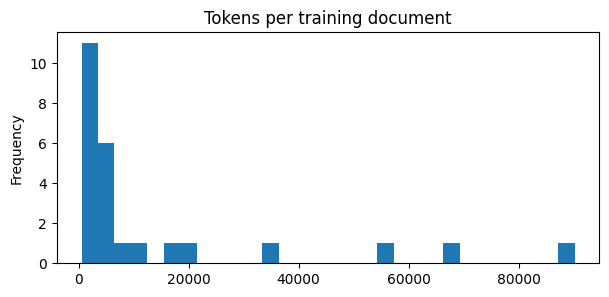

Total tokens: 391,053 | avg document length: 7,821 tokens | packed sequences: 170 train + 21 eval


In [10]:
from src.tokenize_pack import load_tokenizer
tokenizer = load_tokenizer()
train_blocks = pd.read_parquet(config.PROCESSED_DIR / "train_packed.parquet")
first = list(train_blocks.input_ids.iloc[0])
print("Block 0 starts with:", tokenizer.convert_ids_to_tokens(first[:12]))
pos = [i for i, t in enumerate(first) if t == tokenizer.eos_token_id][:1]
if pos:
    i = pos[0]; print("Document boundary inside block 0:", tokenizer.decode(first[i-15:i+8]))
doc_tokens = pd.read_csv(config.PROCESSED_DIR / "train_doc_tokens.csv")
doc_tokens.tokens.plot.hist(bins=30, title="Tokens per training document", figsize=(7, 3)); plt.show()
s = tok_stats["splits"]
print(f"Total tokens: {s['train']['total_tokens'] + s['eval']['total_tokens']:,} | avg document length: "
      f"{(s['train']['total_tokens'] + s['eval']['total_tokens']) / (s['train']['documents'] + s['eval']['documents']):,.0f} tokens | "
      f"packed sequences: {s['train']['packed_sequences']} train + {s['eval']['packed_sequences']} eval")

In [11]:
total_words = summary["retained_document_words"]["total"]
total_tokens = s["train"]["total_tokens"] + s["eval"]["total_tokens"]
print(f"* {total_words:,} words -> {total_tokens:,} tokens = {total_tokens / total_words:.2f} tokens/word")
print(f"* eval_unseen: {split['documents_eval_unseen']} whole documents = {split['actual_eval_unseen_word_fraction']:.1%} of words "
      f"({s.get('eval_unseen', {}).get('total_tokens', 0):,} tokens)")
print(f"* Held-out tail: last 10% of {split['documents_eval']} docs = {split['actual_eval_word_fraction']:.1%} of words "
      f"({s['eval']['total_tokens']:,} tokens); train: {s['train']['packed_sequences']} blocks x {config.BLOCK_SIZE}")
print(f"* Train remainder dropped: {s['train']['tokens_dropped_remainder']} tokens "
      f"({100 * s['train']['tokens_dropped_remainder'] / s['train']['total_tokens']:.2f}% of train)")

* 241,533 words -> 391,053 tokens = 1.62 tokens/word
* eval_unseen: 8 whole documents = 6.5% of words (26,508 tokens)
* Held-out tail: last 10% of 25 docs = 9.3% of words (41,584 tokens); train: 170 blocks x 2048
* Train remainder dropped: 1309 tokens (0.37% of train)


**Inferences — Step 2**
* **Tokens per word ≈ 1.62** (241,533 words → 391,053 tokens) — above the ~1.3 typical of general English. HR documents contain many strings the general-purpose LLaMA vocabulary splits into several pieces: upper-case headings (block 0 starts `▁Document ▁Type ▁Policy … Organ ization`), abbreviations (EL, CL, ICC, TA/DA), band codes (E1, J2, M3), clause numbers (4.1, a), ii.) and amounts (`Rs.10`, `3500/-`).
* **Held-out sets.** `eval` = the last 10 % of each of 25 documents = **9.3 % of words (41,584 tokens)**, cut at paragraph breaks; `eval_unseen` = **8 whole documents (6.5 % of words, 26,508 tokens)** never used for training. Taking the tail of *every* document keeps the main held-out set representative: documents span ~300 to ~58,000 words, so a few whole documents would be either tiny or dominated by one manual. Caveat: both sets were scored during the Step 4a sweep, so neither is an untouched final test set (see Step 5).
* **Packing.** Training: 349,469 tokens → **170 blocks × 2048**, zero padding; only 1,309 tail tokens (0.37 %) are dropped. Each document is wrapped `<s> … </s>`, so the 25 document boundaries inside the stream are explicit.
* **Average training document ≈ 14,000 tokens vs. a 2048-token context**, so long manuals span many consecutive blocks; packing (instead of one-document-per-sequence with truncation) is what lets CPT see the whole of each manual.

## Step 3 — Model loading & architecture inspection  [2 marks]
Loaded with `AutoModelForCausalLM.from_pretrained(..., dtype=torch.bfloat16)` and gradient checkpointing enabled (the assignment's T4 setting; on A100/L40S bf16 is also the natural choice).

In [12]:
from src.model_utils import load_model, architecture_audit, generate, save_json
model = load_model(config.MODEL_ID, dtype=torch.bfloat16, gradient_checkpointing=True)
audit = architecture_audit(model, tokenizer)
save_json(audit, config.EVAL_DIR / "architecture_audit.json")
display(pd.Series(audit, name="value").to_frame())
print(model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,value
model_type,llama
architectures,[LlamaForCausalLM]
total_parameters,1100048384
trainable_parameters,1100048384
trainable_percent,100.0
num_decoder_layers,22
num_attention_heads,32
num_key_value_heads,4
hidden_size,2048
head_dim,64


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [13]:
print(f"Trainable parameters: {audit['trainable_parameters']:,} ({audit['trainable_parameters']/1e9:.2f} B)")
print(f"Decoder layers {audit['num_decoder_layers']} | attention heads {audit['num_attention_heads']} "
      f"(KV heads {audit['num_key_value_heads']}) | hidden {audit['hidden_size']} | head dim {audit['head_dim']}")
print(f"lm_head {audit['lm_head_shape']} -> output dim {audit['lm_head_shape'][0]} == vocab {audit['config_vocab_size']}: "
      f"{audit['lm_head_out_equals_vocab']}")
baseline = generate(model, tokenizer, config.DOMAIN_PROMPTS)
save_json([{"prompt": p, "base_output": o} for p, o in zip(config.DOMAIN_PROMPTS, baseline)],
          config.EVAL_DIR / "baseline_generations.json")
display(pd.DataFrame({"prompt": config.DOMAIN_PROMPTS, "base model output (before CPT)": baseline}))
del model; import gc; gc.collect(); torch.cuda.empty_cache()

Trainable parameters: 1,100,048,384 (1.10 B)
Decoder layers 22 | attention heads 32 (KV heads 4) | hidden 2048 | head dim 64
lm_head [32000, 2048] -> output dim 32000 == vocab 32000: True


,prompt,base model output (before CPT)
0,"Under the MyGov Leave Policy, resources are eligible to avail during the probation only",.\nThe employees who have been on leave for more than 15 days will be paid a pro-rata salary for that period of time. The employee is also entitled to receive a pro-rata salary for any leave taken...
1,"According to the MyGov Domestic Travel Policy, a resource who drives his own vehicle can claim expenses @",100% of actual costs.\nAirline tickets and hotel bookings are not eligible for reimbursement under this policy.\nThe policy does not cover:\n• Expenditure on meals or refreshments (including alcoh...
2,"As per the MyGov Exit Policy, either party may terminate the Agreement by giving a written notice of",termination to the other party. The parties shall be bound by this clause only if they have entered into an agreement in writing and signed by both parties.\n10.2 Termination for breach: Either pa...


**Inferences — Step 3**
* **Parameter count:** 1,100,048,384 (1.10 B), all trainable — CPT updates the full model, not adapters.
* **Architecture:** 22 decoder layers, hidden size 2048, 32 query heads × head dim 64 (2048 / 32), but only **4 key/value heads** — *grouped-query attention* (8 query heads share one KV head). That is why `k_proj`/`v_proj` are 2048→256 while `q_proj`/`o_proj` are 2048→2048; it shrinks the KV-cache 8×. SwiGLU MLP (5632), RMSNorm, RoPE up to 2048 positions.
* **lm_head check passes:** 2048 → 32,000 = tokenizer vocabulary = config `vocab_size`, so every logit maps to exactly one token id — required for correct cross-entropy/perplexity. Input embeddings and lm_head are *not* tied.
* **Baseline outputs are fluent but invented:** for probation leave the base model talks about pro-rata salary after 15 days of leave (MyGov: only casual/sick leave during probation); for own-vehicle travel it says “100 % of actual costs” (MyGov: Rs.10 per km); for the exit notice it produces generic contract boilerplate (MyGov: 60 days' written notice after 3 years' service, 90 days after 5 years). This is the reference point for Step 5 and Part B.
* **Precision:** the L40S (compute capability 8.9) has native bf16, so Step 4 trains with fp32 master weights + bf16 autocast; on a T4 (cc 7.5) the same code switches to fp16 autocast automatically.

## Step 4 — CPT training loop & loss analysis  [2 marks]

* `PackedDataset` (a `torch.utils.data.Dataset`) wraps the Parquet blocks; `labels = input_ids` (the causal shift happens inside the model).
* `LossRecorderCallback` (a custom `TrainerCallback`) captures loss, learning rate and grad-norm at **every** logging step (`logging_steps=1`) and the held-out loss every ~1/8 of training.

| Hyper-parameter | Value | Reason |
|---|---|---|
| learning rate / tokens per update | **chosen by the Step 4a ablation** from 5e-5 (16 K tok) · 1e-4 (8 K tok) · 2e-4 (8 K tok); cosine, 10 % warm-up | all ≤ TinyLlama's pre-training peak LR (4e-4). Earlier lab runs at 2e-5 / 5e-5 with 16 K tokens per update reduced held-out PPL by only 3–7 % with no forgetting — the model was barely moving |
| effective batch | 1 × 8 grad-accum × 2048 = 16 384 tokens/update | fits a 16 GB T4 as well as the 48 GB L40S; stable gradients |
| epochs | 2 | small corpus — a second pass helps adaptation; more risks memorisation & forgetting |
| precision | fp32 master weights + fp16 autocast (T4) / bf16 autocast (A100) | pure-bf16 Adam updates of ~lr ≈ 5e-5 fall below bf16 resolution and are lost |
| optimiser | paged 8-bit AdamW | 1.1 B × 2 Adam states in 8-bit ≈ 2.2 GB instead of 8.8 GB |
| memory savers | gradient checkpointing, batch 1 | activations recomputed in backward |
| grad clip / weight decay | 1.0 / 0.01 | standard |

*If the T4 runs out of memory, set `os.environ["BLOCK_SIZE"]="1024"` and re-run from Step 2.*

### 4a — Learning-rate / update-count ablation
Three candidates with the **same token budget** (2 epochs) are trained in memory (no checkpoint — the lab disk holds only one) and scored on held-out perplexity and on the three general-knowledge prompts of Step 5B. **Selection rule:** lowest held-out PPL among candidates that keep all three general facts (a catastrophic-forgetting guard). The winner is then retrained and saved. ~6–8 min on an L40S. (Set `CPT_SWEEP=0` to skip and use the defaults in `src/config.py`.)

In [14]:
from src.train_cpt import train_cpt
if os.environ.get("CPT_SWEEP", "1") == "1":
    from src.cpt_sweep import run_sweep
    sweep_table, best_hp = run_sweep()
    display(sweep_table)
    print("Selected hyper-parameters:", best_hp)
else:
    sweep_table, best_hp = None, {}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Base PPL: {'eval': 7.051, 'eval_unseen': 6.528}

=== A: lr 5e-5, 16K tok/update ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Starting loss (pretrained, before CPT): train 1.970 | held-out 1.953
CPT: 170 blocks x 2048 tokens, 44 optimiser updates, bf16 mixed precision, optimiser OptimizerNames.PAGED_ADAMW_8BIT


Step,Training Loss,Validation Loss
5,2.062426,1.951427
10,1.995947,1.922367
15,1.844011,1.905080
20,1.690683,1.889436
25,1.114261,1.909523
30,1.221078,1.926276
35,1.046918,1.910322
40,1.095376,1.909642
44,1.436033,1.908881


...

Starting loss (pretrained, before CPT): train 1.970 | held-out 1.953
CPT: 170 blocks x 2048 tokens, 86 optimiser updates, bf16 mixed precision, optimiser OptimizerNames.PAGED_ADAMW_8BIT


Step,Training Loss,Validation Loss
10,2.334081,2.226192
20,2.342391,2.252834
30,2.133934,2.246476
40,1.991538,2.210418
50,1.365859,2.330906
60,1.195009,2.287458
70,1.242246,2.246164
80,1.037207,2.215510
86,1.010438,2.211835


{'heldout_ppl': 8.986, 'heldout_ppl_drop_%': -27.44, 'general_facts_kept': '0/3'}

Selected: A: lr 5e-5, 16K tok/update


,candidate,learning_rate,gradient_accumulation_steps,updates,final_train_loss,final_heldout_loss,heldout_ppl,heldout_ppl_drop_%,general_facts_kept,unseen_ppl_drop_%
0,"A: lr 5e-5, 16K tok/update",0.00005,8,44,1.436033,1.908881,6.654,5.63,3/3,9.27
1,"B: lr 1e-4, 8K tok/update",0.00010,4,86,1.184150,2.040535,7.588,-7.62,1/3,-0.35
2,"C: lr 2e-4, 8K tok/update",0.00020,4,86,1.010438,2.211835,8.986,-27.44,0/3,-16.30


Selected hyper-parameters: {'learning_rate': 5e-05, 'gradient_accumulation_steps': 8}


### 4b — Final CPT run with the selected hyper-parameters

In [15]:
cpt_summary, loss_rows = train_cpt(hparams=best_hp)
display(pd.Series(cpt_summary).to_frame("value"))

Disk space for checkpoint: 2.7 GiB available (need ~2.3 GiB)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Starting loss (pretrained, before CPT): train 1.970 | held-out 1.953
CPT: 170 blocks x 2048 tokens, 44 optimiser updates, bf16 mixed precision, optimiser OptimizerNames.PAGED_ADAMW_8BIT


Step,Training Loss,Validation Loss
5,2.062883,1.951595
10,1.995764,1.922630
15,1.843937,1.905480
20,1.690447,1.889727
25,1.114411,1.909674
30,1.221450,1.925944
35,1.047533,1.910220
40,1.095154,1.909265
44,1.435399,1.908895


Writing model shards:   0%|          | 0/5 [00:00<?, ?it/s]

Saved CPT model + tokenizer to /home/jovyan/datavol-1/CorpPolicyLM/models/cpt (1.2 min)


,value
model_id,TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T
precision,bf16 mixed precision
optimizer,paged_adamw_8bit
train_blocks,170
block_size,2048
tokens_per_update,16384
optimizer_updates,44
hyperparameters,"{'learning_rate': 5e-05, 'num_train_epochs': 2, 'max_steps': -1, 'per_device_train_batch_size': 1, 'gradient_accumulation_steps': 8, 'warmup_ratio': 0.1, 'weight_decay': 0.01, 'lr_scheduler_type':..."
start_train_loss,1.9704
start_eval_loss,1.9527


**Superseded by the revised loss analysis below.** The automatic “train plateau” marker in this first plot is misleading; the revised loss-curve reading marks the held-out minimum instead.

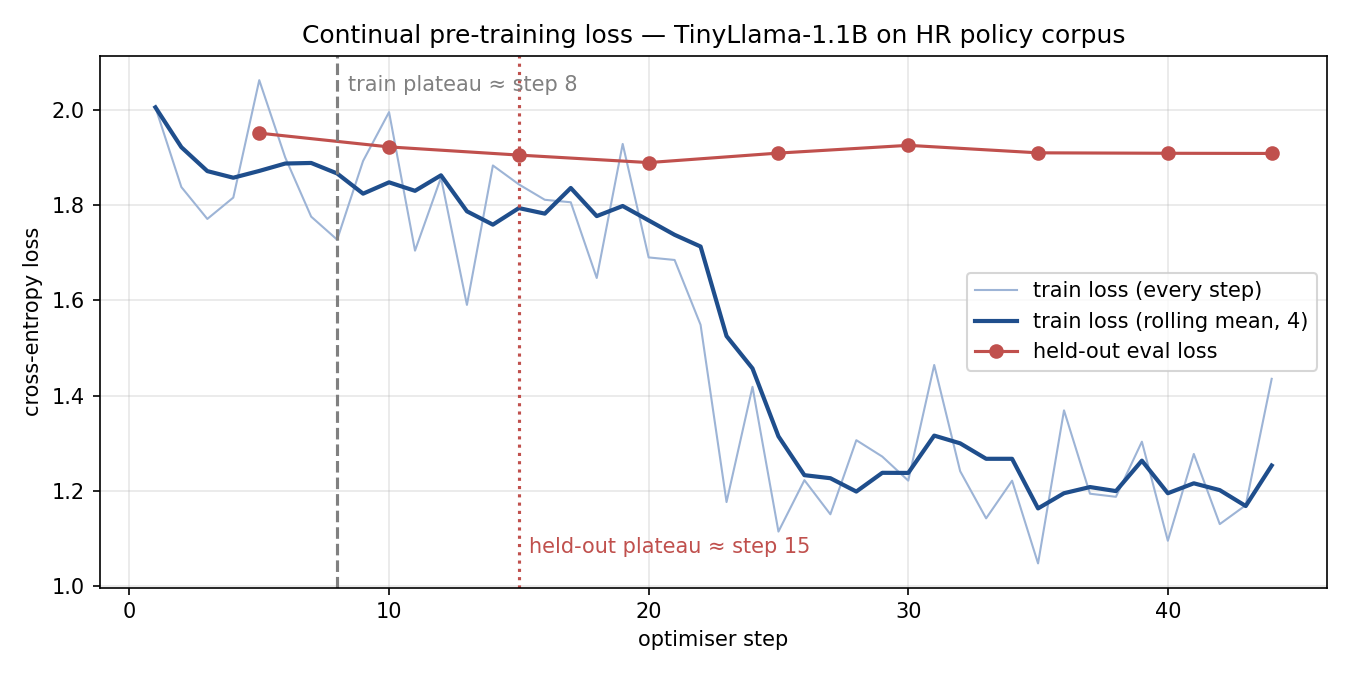

,value
first_logged_loss,2.005803
last_logged_loss,1.435399
min_loss,1.047533
loss_drop_percent,32.550000
plateau_step,8.000000
eval_plateau_step,15.000000
final_train_eval_gap,-0.655700
first_eval_loss,1.951595
last_eval_loss,1.908895


CPT loss 1.9704 → 1.4354: 27.15% endpoint decrease. The 32.55% ('loss_drop_percent' above) refers to window means (first vs last logged steps).


In [16]:
from src.evaluate_cpt import plot_loss_curve
loss_stats, png = plot_loss_curve()
from IPython.display import Markdown
display(Markdown("**Superseded by the revised loss analysis below.** The automatic “train plateau” "
                 "marker in this first plot is misleading; the revised loss-curve reading marks the "
                 "held-out minimum instead."))
display(Image(str(png)))
display(pd.Series(loss_stats).to_frame("value"))
endpoint = 100 * (1 - loss_stats['last_logged_loss'] / cpt_summary['start_train_loss'])
print(f"CPT loss {cpt_summary['start_train_loss']:.4f} → {loss_stats['last_logged_loss']:.4f}: "
      f"{endpoint:.2f}% endpoint decrease. The {loss_stats['loss_drop_percent']}% "
      f"('loss_drop_percent' above) refers to window means (first vs last logged steps).")

#### Step 4 — revised loss-curve reading (added after the run; reads the saved log, no retraining)
The automatic “train plateau” annotation above is replaced by the held-out minimum, and the two loss-drop definitions are printed side by side.

Endpoint change      : 1.9704 -> 1.4354 = -27.15%
Window means (w=4)   : 1.8579 -> 1.2532 = -32.55%  (= 'loss_drop_percent' above)
Held-out loss        : before 1.9527 | minimum 1.8897 at step 20 | final 1.9089 (+1.01% vs minimum)


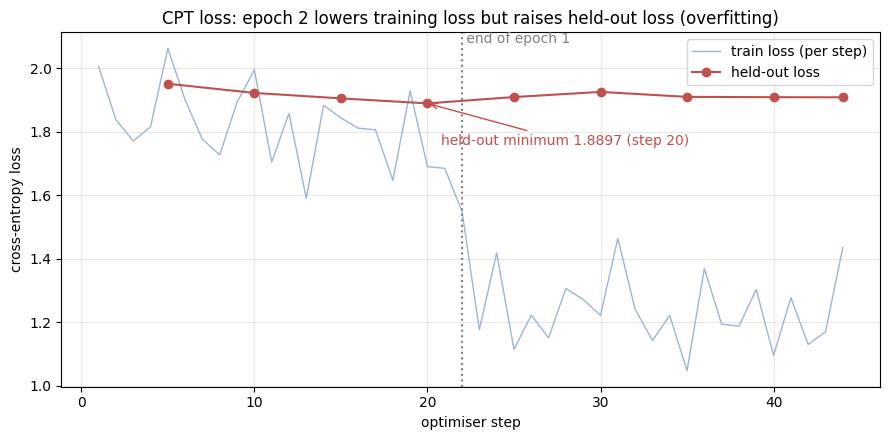

In [27]:
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd
pd.set_option("display.max_colwidth", None)
from src import config
EVAL = config.EVAL_DIR
import matplotlib.pyplot as plt
log = pd.read_csv(EVAL / "cpt_loss_log.csv")
tr, ev = log.dropna(subset=["loss"]), log.dropna(subset=["eval_loss"])
training_summary = json.load(open(EVAL / "cpt_training_summary.json"))
start, end = training_summary["start_train_loss"], float(tr["loss"].iloc[-1])
w = max(3, len(tr) // 10)
first_w, last_w = tr["loss"].iloc[:w].mean(), tr["loss"].iloc[-w:].mean()
best = ev.loc[ev["eval_loss"].idxmin()]
print(f"Endpoint change      : {start:.4f} -> {end:.4f} = -{100 * (start - end) / start:.2f}%")
print(f"Window means (w={w})   : {first_w:.4f} -> {last_w:.4f} = -{100 * (1 - last_w / first_w):.2f}%  (= 'loss_drop_percent' above)")
print(f"Held-out loss        : before {training_summary['start_eval_loss']:.4f} | minimum {best['eval_loss']:.4f} at step {int(best['step'])} "
      f"| final {ev['eval_loss'].iloc[-1]:.4f} (+{100 * (ev['eval_loss'].iloc[-1] / best['eval_loss'] - 1):.2f}% vs minimum)")
updates_per_epoch = training_summary["optimizer_updates"] / training_summary["hyperparameters"]["num_train_epochs"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tr["step"], tr["loss"], color="#9db4d6", lw=1, label="train loss (per step)")
ax.plot(ev["step"], ev["eval_loss"], "o-", color="#c0504d", label="held-out loss")
ax.axvline(updates_per_epoch, ls=":", color="grey"); ax.text(updates_per_epoch, ax.get_ylim()[1], " end of epoch 1", va="top", color="grey")
ax.annotate(f"held-out minimum {best['eval_loss']:.4f} (step {int(best['step'])})", (best["step"], best["eval_loss"]),
            xytext=(10, -30), textcoords="offset points", arrowprops=dict(arrowstyle="->", color="#c0504d"), color="#c0504d")
ax.set_xlabel("optimiser step"); ax.set_ylabel("cross-entropy loss"); ax.grid(alpha=.3); ax.legend()
ax.set_title("CPT loss: epoch 2 lowers training loss but raises held-out loss (overfitting)")
plt.tight_layout(); plt.savefig(config.FIGURE_DIR / "cpt_loss_curve_revised.png", dpi=150); plt.show()

In [17]:
log = pd.DataFrame(loss_rows)
tr = log.dropna(subset=["loss"]); ev = log.dropna(subset=["eval_loss"])
steps_per_epoch = cpt_summary["optimizer_updates"] / cpt_summary["hyperparameters"]["num_train_epochs"]
e1 = tr[tr.step <= steps_per_epoch].loss.mean(); e2 = tr[tr.step > steps_per_epoch].loss.mean()
print(f"* Start (pretrained) loss {cpt_summary['start_train_loss']:.3f} -> final {loss_stats['last_logged_loss']:.3f}; "
      f"mean train loss epoch 1 {e1:.3f} vs epoch 2 {e2:.3f}")
print(f"* Held-out loss {cpt_summary['start_eval_loss']:.3f} (before) -> {ev.eval_loss.iloc[0]:.3f} (first eval) -> "
      f"{ev.eval_loss.iloc[-1]:.3f} (end); held-out minimum {ev.eval_loss.min():.4f} at step {int(ev.loc[ev.eval_loss.idxmin(), 'step'])}")
print(f"* Final train−eval gap {loss_stats['final_train_eval_gap']:+.3f} (negative = training loss below held-out loss)")

* Start (pretrained) loss 1.970 -> final 1.435; mean train loss epoch 1 1.809 vs epoch 2 1.235
* Held-out loss 1.953 (before) -> 1.952 (first eval) -> 1.909 (end); held-out minimum 1.8897 at step 20
* Final train−eval gap -0.656 (negative = training loss below held-out loss)


**Inferences — Step 4**
* **Ablation (4a) — larger, more frequent updates overfit and forget.** With the same 2-epoch token budget:

  | candidate | updates | final train loss | held-out loss | held-out PPL | general-fact probes kept |
  |---|---|---|---|---|---|
  | A: lr 5e-5, 16 K tok/update | 44 | 1.44 | **1.91** | **6.654 (−5.6 %)** | **3/3** |
  | B: lr 1e-4, 8 K tok/update | 86 | 1.18 | 2.04 | 7.588 (+7.6 %, worse) | 1/3 |
  | C: lr 2e-4, 8 K tok/update | 86 | 1.01 | 2.21 | 8.986 (+27.4 %, worse) | 0/3 |

  As the step size grows, the *training* loss falls (1.44 → 1.18 → 1.01) while the held-out loss *rises* (1.91 → 2.04 → 2.21) and fewer general-fact probes survive — overfitting of a 0.35 M-token corpus together with forgetting, the risk described in the assignment's tip. **A** is selected. **Selection caveat:** the held-out PPL and the three general-fact prompts were the selection criteria, so the Step 5 figures for these sets are *selection-set* results, not an independent test (A was also the pre-chosen default, which limits — but does not remove — this concern).
* **Correct starting point.** The pretrained loss on the training blocks is **1.9704** (held-out 1.9527) — at the low end of the expected 2–4 band, as expected for formulaic English prose; a randomly initialised LLaMA would start near ln 32,000 ≈ 10.4 (`train_cpt` aborts above 8).
* **How much the loss fell — two different numbers.** Endpoint change: **1.9704 → 1.4354 = −27.15 %**. The **32.55 %** printed by the loss-curve cell is a *different* quantity: the mean of the last few logged steps versus the mean of the first few (window = max(3, n/10) steps), which damps the per-step noise. The revised cell below prints both.
* **Where the curve plateaus — validation, not training.** The “train plateau ≈ step 8” annotation comes from an automatic rolling-window detector and is misleading: the training loss keeps falling sharply in the second epoch (epoch means 1.81 → 1.24). The meaningful turning point is the **held-out loss, which reaches its minimum 1.8897 at step 20 (end of epoch 1, 22 updates) and then rises to 1.9089 by the end**. The second epoch therefore reduced training loss but *worsened* validation loss relative to the first-epoch minimum — **overfitting**. We kept the final (end-of-epoch-2) checkpoint, which is permissible but ≈1 % worse in held-out loss than the best observed point; early stopping after epoch 1 would have been the better choice.
* **Resources:** 44 updates × 16,384 tokens ≈ 0.72 M tokens in 1.2 min on the L40S; peak GPU memory **14.73 GB** (fp32 weights + paged 8-bit AdamW + gradient checkpointing — tight for a 16 GB T4). The bf16 checkpoint (2.05 GiB) is saved to `models/cpt/`.

## Step 5 — Evaluation: perplexity & catastrophic forgetting  [2 marks]

### 5A — Domain perplexity
$$\text{PPL} = \exp\Big(-\tfrac{1}{N}\sum_{i}\log P(t_i\mid t_1\dots t_{i-1})\Big)$$
computed with a no-grad cross-entropy loop over **every** token of the held-out documents (never seen in CPT), for the base and the CPT model.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

base model PPL on eval        (held-out last 10% of every document): 7.051 over 41,563 tokens
base model PPL on eval_unseen (whole documents never seen in CPT): 6.528 over 26,495 tokens


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 cpt model PPL on eval        (held-out last 10% of every document): 6.655 over 41,563 tokens
 cpt model PPL on eval_unseen (whole documents never seen in CPT): 5.920 over 26,495 tokens


,value
eval_tokens,41563
base_ppl,7.0511
cpt_ppl,6.6551
ppl_reduction_percent,5.62
unseen_eval_tokens,26495
unseen_base_ppl,6.5277
unseen_cpt_ppl,5.9203
unseen_ppl_reduction_percent,9.31
within_expected_10_40_percent,False


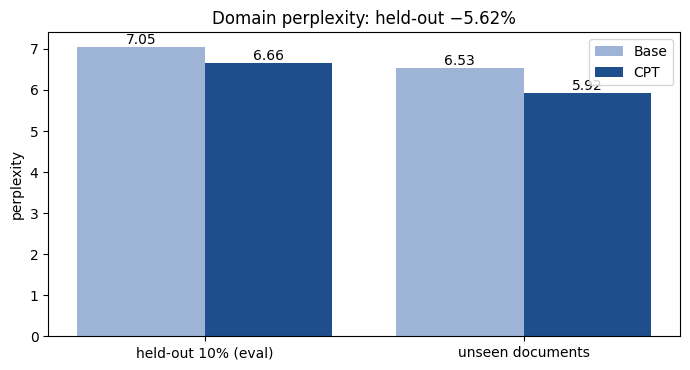

In [18]:
from src.evaluate_cpt import domain_perplexity
ppl = domain_perplexity()
display(pd.Series(ppl).to_frame("value"))
fig, ax = plt.subplots(figsize=(7, 3.8))
labels, base_v, cpt_v = ["held-out 10% (eval)"], [ppl["base_ppl"]], [ppl["cpt_ppl"]]
if "unseen_base_ppl" in ppl:
    labels.append("unseen documents"); base_v.append(ppl["unseen_base_ppl"]); cpt_v.append(ppl["unseen_cpt_ppl"])
import numpy as np
x = np.arange(len(labels))
ax.bar(x - 0.2, base_v, 0.4, label="Base", color="#9db4d6"); ax.bar(x + 0.2, cpt_v, 0.4, label="CPT", color="#1f4e8c")
for xi, b, c in zip(x, base_v, cpt_v):
    ax.text(xi - 0.2, b, f"{b:.2f}", ha="center", va="bottom"); ax.text(xi + 0.2, c, f"{c:.2f}", ha="center", va="bottom")
ax.set_xticks(x, labels); ax.legend(); ax.set_ylabel("perplexity")
ax.set_title(f"Domain perplexity: held-out −{ppl['ppl_reduction_percent']}%"); plt.tight_layout()
plt.savefig(config.FIGURE_DIR / "perplexity_base_vs_cpt.png", dpi=150); plt.show()

### 5B — Catastrophic-forgetting check
Both models complete three general-knowledge prompts (greedy decoding). Verdict: **Retained** if the CPT output still contains the fact, **Degraded** if the base model had it and the CPT model lost it.

In [19]:
from src.evaluate_cpt import forgetting_check
forgetting, domain_gen = forgetting_check()
display(forgetting[["prompt", "base_output", "cpt_output", "expected_fact", "verdict"]])
print("Domain prompts — base vs CPT completions:")
display(domain_gen)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,prompt,base_output,cpt_output,expected_fact,verdict
0,The capital of France is,"Paris.\nThe capital of the United States is Washington, D.C.\nThe capital of Canada is Ottawa.\nThe capital of Australia is Canberra.\nThe capital of New Zealand is Wellington.\nThe capital of Sou...",Paris.\n\n10.2.3.4. The capital of India is New Delhi.\n\n10.2.3.5. The capital of the United Kingdom is London.\n\n10.2.3.6. The capital of the United States is,paris,Retained
1,Water boils at,"212 degrees Fahrenheit.\nThe temperature of water is a measure of the amount of energy in the molecules that make up the water. The higher the temperature, the more energy is available to do work ...",100 degrees Celsius.\n\n2.3.4. The following are the minimum qualifications for various posts in the Institute:\n\nSl. No Qualification Minimum Age (years)\nPosts Grade Pay (Rs.)\nLevel 9 &,100 / 212,Retained
2,The speed of light is approximately,"300,000 km/s.\nThe speed of sound in air is about 1,250 m/s.\nThe speed of sound in water is about 940 m/s.\nThe speed of sound in a gas is about 7","300,000 km/s.\n\n12.4.5.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1","300,000 / 300000",Retained


Domain prompts — base vs CPT completions:


,prompt,base_output,cpt_output,reference_fact,base_mentions_fact,cpt_mentions_fact
0,"Under the MyGov Leave Policy, resources are eligible to avail during the probation only",.\nThe employees who have been on leave for more than 15 days will be paid a pro-rata salary for that period of time. The employee is also entitled to receive a pro-rata salary for any leave taken...,.\n\n10.3.2.4. The leave will be credited in the account of the employee on a monthly basis and can be availed at any time as per the calendar year.\n\n10.3.2.5. Apart from the above,casual / sick,False,False
1,"According to the MyGov Domestic Travel Policy, a resource who drives his own vehicle can claim expenses @",100% of actual costs.\nAirline tickets and hotel bookings are not eligible for reimbursement under this policy.\nThe policy does not cover:\n• Expenditure on meals or refreshments (including alcoh...,10% of the eligible\ntravel amount.\n\n3.2.4.5 The following rules will apply for travel by air:\n\n• A maximum of two bags per person are allowed in economy class and one bag in premium class.\n•...,rs.10 / rs. 10,False,False
2,"As per the MyGov Exit Policy, either party may terminate the Agreement by giving a written notice of",termination to the other party. The parties shall be bound by this clause only if they have entered into an agreement in writing and signed by both parties.\n10.2 Termination for breach: Either pa...,"30 days to\nthe other. In case of termination, all the rights and obligations under this agreement will cease from the date of such termination.\n12.4 Termination for Convenience: Either party may...",60 days / sixty,False,False


In [20]:
print(f"* Domain PPL base {ppl['base_ppl']:.2f} -> CPT {ppl['cpt_ppl']:.2f}: −{ppl['ppl_reduction_percent']}% "
      f"on the held-out 10% ({ppl['eval_tokens']:,} tokens; expected range 10–40%: {ppl['within_expected_10_40_percent']})")
if "unseen_base_ppl" in ppl:
    print(f"* Unseen documents: base {ppl['unseen_base_ppl']:.2f} -> CPT {ppl['unseen_cpt_ppl']:.2f}: "
          f"−{ppl['unseen_ppl_reduction_percent']}% ({ppl['unseen_eval_tokens']:,} tokens)")
print("* Forgetting verdicts:", {k: int(v) for k, v in forgetting.verdict.value_counts().items()})
print("* Domain probe facts — base:", int(domain_gen.base_mentions_fact.sum()), "/ 3, CPT:",
      int(domain_gen.cpt_mentions_fact.sum()), "/ 3")

* Domain PPL base 7.05 -> CPT 6.66: −5.62% on the held-out 10% (41,563 tokens; expected range 10–40%: False)
* Unseen documents: base 6.53 -> CPT 5.92: −9.31% (26,495 tokens)
* Forgetting verdicts: {'Retained': 3}
* Domain probe facts — base: 0 / 3, CPT: 0 / 3


**Inferences — Step 5**
* **5A — a positive but modest adaptation.** Held-out 10 %: PPL **7.051 → 6.655 (−5.62 %)**; unseen documents: **6.528 → 5.920 (−9.31 %)**. Neither set was used for training, so the drop is not memorisation of the evaluated text. It is below the 10–40 % the assignment describes as *typical*. Likely reasons, consistent with our results but not separately tested:
  1. **The base model already predicts this text well** (PPL ≈ 7): policy prose is formulaic English and TinyLlama's 3 T-token pre-training contains a lot of similar text.
  2. **The corpus is small** — 0.35 M training tokens, 44 updates.
  3. **More aggressive CPT did not help here** — in Step 4a, larger/more frequent updates made held-out PPL worse. Within the settings we tried, −5.6 % was the best result; a larger corpus is the obvious next step.
* **Caveat on independence.** Both PPL sets were reported during the Step 4a sweep and the held-out PPL drove the selection, so these are selection-set figures; a fresh, untouched test set would be needed for an unbiased estimate.
* **Unseen documents improved *more* (−9.31 %) than held-out tails (−5.62 %).** A plausible explanation (a hypothesis, not tested): the unseen set consists of short POSH / whistle-blower / code-of-conduct / human-rights policies whose wording follows statutory templates (POSH Act, SEBI vigil-mechanism rules) that recur across companies in the training data, while the held-out tails of long manuals end in annexures, pay tables and organisation-specific rules.
* **5B — the three general-fact probes were retained** (Paris; 100 °C; 300,000 km/s). These same three prompts were the forgetting guard in the Step 4a selection, so they are **selection probes, not independent evidence of broad knowledge retention**; a held-out set of general questions or a general-text perplexity would be needed for that claim. Only the continuation style changed (“10.2.3.4. The capital of India is New Delhi…”), a visible sign of domain adaptation. In the sweep, the same probes were lost at LR ≥ 1e-4 (1/3 and 0/3 kept).
* **Domain probes (raw completions).** The CPT completions sound like an HR manual but give other organisations' numbers (e.g. “30 days” notice instead of MyGov's 60/90 days, a percentage instead of Rs.10 per km). CPT teaches the *language* of the domain; recalling one organisation's specific rule needs instruction tuning or retrieval.

# PART B — Instruction Fine-Tuning with QLoRA

## B1 — Instruction dataset creation  [2 marks]
**Source:** the cleaned `data/domain_corpus/*.txt` from Step 1. **Format:** JSONL with `instruction` and `response` (+ provenance: `source`, `section`, `type`).

**Method — heuristic generation (`src/instruction_data.py`, default; offline & reproducible):** each policy is parsed into numbered/ALL-CAPS sections and list-item clauses, then converted with four templates; every response is copied verbatim from the policy, so answers are grounded by construction:

| Type | Instruction template | Response |
|---|---|---|
| `section_qa` | What does the *{policy}* say about *{section}*? | section text (≤ 180 words) |
| `section_sum` | Summarise the *'{section}'* provisions of the *{policy}*. | first two sentences |
| `clause_rule` | What does the *{policy}* require regarding *{subject}*? (subject = noun phrase before *shall / must / is entitled / is eligible …*) | the clause |
| `clause_cloze` | Complete this rule from the *{policy}* (section …): "*first half* …" | the full clause |

Long manuals are capped at 150 pairs per document so they do not dominate. Duplicated instructions are removed.

**Optional — LLM synthetic generation** (`build_instruction_dataset("llm")`, needs `ANTHROPIC_API_KEY` or `OPENAI_API_KEY`). Exact prompt template used per 600-word chunk:
```
Read the text below and generate {n} instruction-response pairs in JSON format based ONLY on this text. Each entry must have instruction and response keys.
The instruction must be a question an employee or HR executive would realistically ask; the response must answer it using only facts stated in the text (quote numbers, limits and conditions exactly). Return a JSON list only, with no commentary.

Document: {title}
---
{chunk}
---
```
**Split:** 80 / 20 by *section group* — all pairs generated from the same section go to the same split, so the eval set measures generalisation to unseen clauses rather than re-phrasings of training clauses.

In [21]:
from src.instruction_data import build_instruction_dataset
METHOD = "heuristic"   # or "llm" if an API key is configured
inst_stats = build_instruction_dataset(METHOD)
inst = pd.read_json(config.INSTRUCTION_DIR / "instruction_dataset.jsonl", lines=True)
print(f"Train: {inst_stats['train_pairs']} | Eval: {inst_stats['eval_pairs']} | Total: {inst_stats['total_pairs']}")
display(inst.groupby("type").size().to_frame("pairs"))
display(inst.sample(8, random_state=1)[["type", "instruction", "response", "source"]])

{
  "method": "heuristic",
  "total_pairs": 1852,
  "train_pairs": 1484,
  "eval_pairs": 368,
  "train_fraction": 0.801,
  "documents": 33,
  "pairs_by_type": {
    "clause_cloze": 769,
    "clause_rule": 475,
    "section_qa": 381,
    "section_sum": 227
  },
  "split_unit": "section group (no clause appears in both splits)",
  "llm_prompt_template": null
}
Train: 1484 | Eval: 368 | Total: 1852


,pairs
type,
clause_cloze,769
clause_rule,475
section_qa,381
section_sum,227


,type,instruction,response,source
462,section_sum,Summarise the 'PROTECTION' provisions of the BEML Whistle Blower Policy.,12.1 No unfair treatment will be meted out to a Whistle Blower by virtue of his / her having reported a Protected Disclosure under this policy. Adequate safeguards against victimisation of complai...,beml_whistle_blower_policy.txt
1081,clause_cloze,"Complete this rule from the IIHMR HR Policy Manual (section 'RECRUITMENT AND SELECTION'): ""On receipt o f shortlisted CVs from President/Director /Deans/HOD, the HR department sends ...""","On receipt o f shortlisted CVs from President/Director /Deans/HOD, the HR department sends invites to the candidates for the interview through written modes of communications. 3.f.",iihmr_hr_policy_manual.txt
1177,section_qa,What does the IIM Raipur HR Policy & Service Rules say about revised executive learning and development policy (minutes of eldc?,Committee Meeting held on 29th November 2022) 1. Program Director(s) share as a coordinator for program(s): • Considering one day of training program which consist of 4 session (90 min each) and e...,iim_raipur_hr_policy_service_rules.txt
1068,clause_cloze,"Complete this rule from the IIHMR HR Policy Manual (section 'ANNUAL APPRAISAL and REVIEW'): ""Appraisal forms a re sent t o all eligible employee of the university/Institute through email with a ...""",Appraisal forms a re sent t o all eligible employee of the university/Institute through email with a request to fill and route it through supervisor for per formance review and submit to the Presi...,iihmr_hr_policy_manual.txt
372,clause_cloze,"Complete this rule from the Bajaj Broking POSH Policy (section 'Standard,'): ""Threats and insinuation that a person’s employment, wages, promotional opportunities, job or shift assignments, or oth...","Threats and insinuation that a person’s employment, wages, promotional opportunities, job or shift assignments, or other conditions of employment may be adversely affected by not submitting to sex...",bajaj_broking_posh_policy.txt
1676,clause_rule,What does the MyGov Laptop Policy require regarding suspension or Discontinuation Laptop Charges?,Suspension or Discontinuation Laptop Charges may be suspended or discontinued in the following circumstances: change in role or eligibility; provision of an organization-owned laptop.,mygov_laptop_policy.txt
241,section_sum,Summarise the 'Departure Of Employee' provisions of the AICB HR Manual.,"Termination An Employment Contract may be terminated by the organisation at any time without notice or payment in lieu of notice whatsoever, except payment of outstanding wages, overtime and earne...",aicb_hr_manual.txt
464,clause_rule,What does the BEML Whistle Blower Policy require regarding adequate safeguards against victimisation of complainants?,Adequate safeguards against victimisation of complainants shall be provided.,beml_whistle_blower_policy.txt


**Inferences — B1**
* **Size and split:** **1,852** pairs from all 33 cleaned documents — **1,484 train / 368 eval (80.1 / 19.9 %)**, split by section group so no clause appears in both sets. The MyGov sections are kept in the training split so B3 tests recall of trained facts.
* **Grounding:** every response is copied from the source policy (no generated text), so responses carry the policy's wording; `source` and `section` give provenance for every pair. Grounded responses are not automatically *clean*, though — see limitations.
* **Mix:** clause-level pairs (769 cloze + 475 rule) dominate and teach precise single-rule answers; 381 section Q&A and 227 section summaries teach longer answers.
* **Quality controls** (added after inspecting earlier versions): tables of contents, annexures, forms and signature/approval blocks are skipped; dot-leader text, page numbers and colon-only intros are rejected (list items are merged into their intro); duplicate responses are removed; documents get curated titles from `data/sources.csv`.
* **Limitations:** quality was spot-checked on samples, not audited systematically. **PDF-extraction artefacts remain** — the conservative repair in Step 1 only joins a split word when the joined form occurs elsewhere in the corpus, so fragments such as “a re sent t o” and “per formance” are still present. Questions are templated (“What does the … require regarding …?”), so the model is less robust to free-form phrasing. The optional LLM method (prompt template above) would add natural paraphrases at the cost of a factuality check.

## B2 — QLoRA fine-tuning with **Adapter B (Balanced)**  [2 marks]
| Setting | Value |
|---|---|
| Base weights | CPT checkpoint from Step 4, **4-bit NF4**, double quantisation, compute dtype bf16 (L40S/A100) or fp16 (T4) |
| Adapter | **B — r = 16, α = 32, target `q_proj`, `v_proj`**, dropout 0.05 |
| Trainer | TRL `SFTTrainer`, prompt/completion conversations rendered with the chat template; loss on the assistant completion only |
| Optimiser / LR | paged 8-bit AdamW, 2e-4, cosine, 5 % warm-up, 2 epochs, batch 4 × grad-accum 4, max length 512 |

**Why Adapter B?** Adapter A (r = 8) risks under-fitting multi-clause answers; Adapter C (r = 32 + `o_proj`) roughly doubles adapter parameters and VRAM for little gain on a ~10³-pair dataset. B is the quality/cost balance point. α/r = 2 keeps the effective LoRA scale the same as the common r=8/α=16 setting.

**Chat template:** the TinyLlama *base* tokenizer has no chat template, so the official TinyLlama-1.1B-Chat-v1.0 (Zephyr-style) template — `<|system|> … </s> <|user|> … </s> <|assistant|> …` — is attached to the same tokenizer (no vocabulary change: the markers are ordinary text tokens).

In [22]:
from src.train_qlora import train_qlora, load_chat_tokenizer
chat_tok = load_chat_tokenizer()
print(chat_tok.apply_chat_template([{"role": "system", "content": config.SYSTEM_PROMPT},
                                    {"role": "user", "content": "How many days of notice are required?"},
                                    {"role": "assistant", "content": "60 days."}], tokenize=False))
sft_summary, sft_rows = train_qlora("B")

<|system|>
You are CorpPolicyLM, an HR policy assistant. Answer using only the organisation's HR and corporate policy documents. Be concise and factual.</s>
<|user|>
How many days of notice are required?</s>
<|assistant|>
60 days.</s>



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/1484 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1484 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1484 [00:00<?, ? examples/s]

...

Dropping fully masked examples from eval dataset:   0%|          | 0/368 [00:00<?, ? examples/s]

Adapter B: r=16, alpha=32, targets=['q_proj', 'v_proj'] -> 2,252,800 trainable / 617,859,072 params (0.365%)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
37,1.334881,1.386163,1.386533,99967.000000,0.686263
74,1.405969,1.348190,1.357101,201954.000000,0.692728
111,1.393185,1.335602,1.343720,304136.000000,0.695042
148,1.311110,1.333735,1.327459,406051.000000,0.695062
185,1.405028,1.333172,1.324565,509006.000000,0.695230
186,1.405028,1.333173,1.324618,510980.000000,0.695063


Training Loss,Validation Loss,Step,Entropy,Num Tokens,Mean Token Accuracy
1.405028,1.333173,186,1.324618,510980.000000,0.695063


{
  "adapter": "B",
  "r": 16,
  "lora_alpha": 32,
  "target_modules": [
    "q_proj",
    "v_proj"
  ],
  "lora_dropout": 0.05,
  "quantization": "4-bit NF4 + double quant",
  "train_pairs": 1484,
  "eval_pairs": 368,
  "trainable_params": 2252800,
  "total_params": 617859072,
  "trainable_percent": 0.3646,
  "optimizer_steps": 186,
  "mean_train_loss": 1.4326,
  "final_eval_loss": 1.3332,
  "train_minutes": 2.3,
  "peak_gpu_memory_gb": 2.74,
  "hyperparameters": {
    "learning_rate": 0.0002,
    "num_train_epochs": 2,
    "max_steps": -1,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "max_length": 512,
    "lora_dropout": 0.05,
    "warmup_ratio": 0.05,
    "logging_steps": 5
  },
  "adapter_dir": "/home/jovyan/datavol-1/CorpPolicyLM/models/adapters/adapter_B"
}


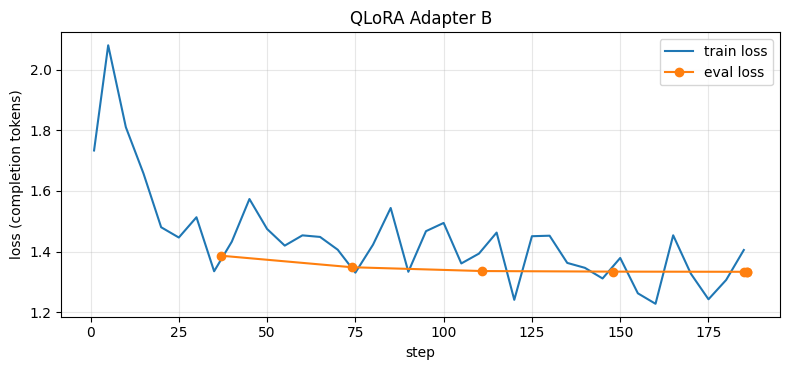

,value
adapter,B
r,16
lora_alpha,32
target_modules,"[q_proj, v_proj]"
lora_dropout,0.05
quantization,4-bit NF4 + double quant
train_pairs,1484
eval_pairs,368
trainable_params,2252800
total_params,617859072


In [23]:
log = pd.DataFrame(sft_rows)
fig, ax = plt.subplots(figsize=(8, 3.8))
t = log.dropna(subset=["loss"]); e = log.dropna(subset=["eval_loss"])
ax.plot(t.step, t.loss, label="train loss"); ax.plot(e.step, e.eval_loss, "o-", label="eval loss")
ax.set_xlabel("step"); ax.set_ylabel("loss (completion tokens)"); ax.set_title("QLoRA Adapter B"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(config.FIGURE_DIR / "sft_adapter_B_loss.png", dpi=150); plt.show()
display(pd.Series({k: v for k, v in sft_summary.items() if k != "hyperparameters"}).to_frame("value"))

**Inferences — B2**
* **Parameter efficiency:** Adapter B trains **2,252,800** parameters (22 layers × [16·(2048+2048) for `q_proj` + 16·(2048+256) for `v_proj`]) = **0.20 % of the 1.10 B model**. The printed 0.365 % is relative to 618 M because 4-bit weights are stored two per byte, so `numel()` of the quantised model counts roughly half the real parameters.
* **Memory and time:** peak GPU memory **2.74 GB** (vs 14.73 GB for full CPT) in 2.3 min — the 4-bit NF4 base needs ~0.7 GB and only the small LoRA matrices carry gradients and optimiser state. This is what makes QLoRA practical on a T4.
* **Learning curve:** 186 steps (2 epochs). Completion-only held-out loss improves **1.3862 → 1.3332** and mean token accuracy **0.686 → 0.695 (≈ 69.5 %)**, with most of the gain in the first epoch; train and held-out loss stay close (≈ 1.3–1.4), so there is no sign of over-fitting.
* **Why the loss stays ≈ 1.3:** responses are verbatim policy clauses, and an unseen clause cannot be predicted word-for-word — much of the remaining loss is content the model cannot know, not a failure to learn the format.

## B3 — Evaluation on the same 3 domain prompts  [1 mark]
The three Step-3/Step-5 topics are asked as questions through the chat template. Columns: raw completions of the base and CPT models (Steps 3/5), the CPT model through the chat template with the adapter **disabled**, and the CPT model **with Adapter B**. Held-out pairs are also scored with ROUGE-L against the reference answers.

**Note:** the `sft_has_fact` and `correct` columns and the counts printed below are *automatic keyword matches*, not factual correctness; they are superseded by the manual review in B3b.

In [24]:
from src.evaluate_sft import evaluate_adapter
domain_cmp, general_cmp, heldout, sft_eval = evaluate_adapter("B")
display(domain_cmp)
display(general_cmp)
display(pd.Series(sft_eval).to_frame("value"))
display(heldout.head(5)[["instruction", "reference", "cpt_no_adapter", "sft_adapter", "rougeL_cpt", "rougeL_sft"]])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{
  "adapter": "B",
  "heldout_pairs_scored": 30,
  "rougeL_cpt_no_adapter": 0.0626,
  "rougeL_sft_adapter": 0.3823,
  "domain_prompts_with_reference_fact": {
    "cpt_no_adapter": 0,
    "sft_adapter": 1
  },
  "general_prompts_correct_after_sft": 2
}


,question,reference_fact,base_completion (Step 3),cpt_completion (Step 5),cpt_chat_no_adapter,sft_adapter_B,cpt_has_fact,sft_has_fact
0,"Under the MyGov Leave Policy, what leave can a resource avail during probation?",casual / sick,.\nThe employees who have been on leave for more than 15 days will be paid a pro-rata salary for that period of time. The employee is also entitled to receive a pro-rata salary for any leave taken...,.\n\n10.3.2.4. The leave will be credited in the account of the employee on a monthly basis and can be availed at any time as per the calendar year.\n\n10.3.2.5. Apart from the above,1. Assistant Professor (Academic)\n2. Assistant Professor (Non-Academic)\n3. Associate Professor (Academic)\n4. Associate Professor (Non-Academic)\n5. Professors (Academic)\n6. Professors (Non-Aca...,"Apart from the leave that is normally admissible to him/her, the following leaves may be granted by the management: • Extraordinary Leave (EoL) for up to 30 days at a time in case of medical emerg...",False,True
1,"Under the MyGov Domestic Travel Policy, how much can a resource claim for driving his own vehicle?",rs.10 / rs. 10,100% of actual costs.\nAirline tickets and hotel bookings are not eligible for reimbursement under this policy.\nThe policy does not cover:\n• Expenditure on meals or refreshments (including alcoh...,10% of the eligible\ntravel amount.\n\n3.2.4.5 The following rules will apply for travel by air:\n\n• A maximum of two bags per person are allowed in economy class and one bag in premium class.\n•...,1. Introduction\n2. Definitions & Interpretations\n3. Authority of the Assistant\n4. Resignation / Retirement\n5. Leave Rules\n6. Duties & Responsibilities\n7. Discipline\n8. Grievance Redressal\n...,The maximum allowance that can be claimed by any one employee while traveling on official duty is Rs. 1000/- per day (exclusive of local conveyance) including daily allowance as admissible under t...,False,False
2,"Under the MyGov Exit Policy, how many days of written notice are needed to terminate the Agreement?",60 days / sixty,termination to the other party. The parties shall be bound by this clause only if they have entered into an agreement in writing and signed by both parties.\n10.2 Termination for breach: Either pa...,"30 days to\nthe other. In case of termination, all the rights and obligations under this agreement will cease from the date of such termination.\n12.4 Termination for Convenience: Either party may...",1. Introduction\n2. Definitions & Interpretations\n3. Resignation / Retirement\n4. Termination by Employee\n5. Termination by Management\n6. Separation from Service\n7. Disciplinary Actions\n8. Co...,"The minimum notice period for termination is 30 days. However, in case of early termination, the employee will be entitled to get his/her salary for the entire month of December.",False,False


,prompt,sft_output,correct
0,The capital of France is,Paris (France) The capital of France is Paris (France).,True
1,Water boils at,100°C at 100 mmHg.,True
2,The speed of light is approximately,108934.25 km/s (92674.44 mph) 108934.25 km/s (92,False


,value
adapter,B
heldout_pairs_scored,30
rougeL_cpt_no_adapter,0.0626
rougeL_sft_adapter,0.3823
domain_prompts_with_reference_fact,"{'cpt_no_adapter': 0, 'sft_adapter': 1}"
general_prompts_correct_after_sft,2


,instruction,reference,cpt_no_adapter,sft_adapter,rougeL_cpt,rougeL_sft
0,What does the MSRLS HR Manual require regarding S/he?,S/he should be a Post Graduate Diploma or Degree in Rural Development / Management / Business Management / Business Administration / Social Work from a premier institute.,Name:\nDesignation:\nEmail Id:\nMobile No.:\nAddress:\nCity: PIN:\nState: District: Block:\nPincode:\nPhone No.:\nDate of Birth:\nNationality: Gender:\nMarital Status:\nCaste:\nEthnicity:\nReligio...,S/he shall be responsible for preparing all the reports required by the Society as per the guidelines of the Government of Meghalaya. 10.2.3.,0.000000,0.120000
1,"Complete this rule from the MSRLS HR Manual (section 'Spm -'): ""Reporting to COO 41000-45000 Child education allowance Rs. 300*2 Child (max), Insurance ...""","Reporting to COO 41000-45000 Child education allowance Rs. 300*2 Child (max), Insurance Cover (Mediclaim and Group Accident) and Annual Performance Pay 015% of basic.",Name:\nDesignation:\nEmail Id:\nMobile No.:\nOffice No.:\nAddress:\nCity: PIN:\nState/ District:\nPincode:\nPhone No.:\nFax No.:\nEmail ID:\nMobile No.:\nOffice No.:\nAddress:\nCity: PIN:\nState/ ...,"Reporting to COO 41000-45000 Child education allowance Rs. 300*2 Child (max), Insurance premium of Rs. 6000/- per child for each year of stay in the institution.",0.000000,0.555556
2,"Complete this rule from the MSRLS HR Manual (section 'Spm -'): ""Government officials from Meghalaya Finance Service with minimum 10 year ...""",Government officials from Meghalaya Finance Service with minimum 10 year of relevant experience will also be eligible for the position.,Name:\nDesignation:\nEmail Id:\nMobile No.:\nAddress:\nCity: PIN:\nState/ District:\nPincode:\nDate of Birth:\nNationality:\nMarital Status:\nNo. of Children:\nNumber of Spouse / Partner:\n\nPhone...,Government officials from Meghalaya Finance Service with minimum 10 years of experience in the field of administration or accounting may be considered for the position of Accountant / Office Assis...,0.085714,0.612245
3,What does the 3M India POSH Policy say about protection against victimisation?,"In the event complainant being an employee and the accused/respondent being her manager/peer/ team member, during the pendency of investigation and even after such investigation if the accused is ...",1. Introduction\n2. Definitions & Interpretations\n3. Compensation\n4. Benefits\n5. Leave Travel Concession (LTC)\n6. Medical facilities\n7. Transport Facilities\n8. Telephone Facilities\n9. Inter...,The Company will take all necessary steps to prevent any kind of victimization of a Whistle Blower or retaliation against him/her in consequence of making a Protected Disclosure under this Policy.,0.026432,0.085308
4,Summarise the 'Protection Against Victimisation' provisions of the 3M India POSH Policy.,"In the event complainant being an employee and the accused/respondent being her manager/peer/ team member, during the pendency of investigation and even after such investigation if the accused is ...","Design a system to monitor the progress of the project in terms of time, budget and quality.\n\nThe system should be able to track all activities related to the project. The system should also\nbe...","The Company will not tolerate any kind of victimization of its employees/workers in terms of discrimination or harassment on account of their gender, sexuality, race, religion, disability, age, ma...",0.186047,0.122699


#### B3a — the adapter on the *same* three prompts as Steps 3 and 5 (added after the run; inference only)
The identical sentence-completion text is given to the adapter (i) raw, exactly as the base and CPT models received it, and (ii) as the user turn of the chat template. **Strict check:** the completion must *begin* with the reference fact (casual/sick leave; Rs.10 per km; 60 or 90 days), so a fact mentioned later alongside contradictions does not count. On a GPU the adapter runs on the 4-bit base exactly as trained; without a GPU it is applied to the bf16 weights (the column *adapter run on* records which).

In [28]:
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd
pd.set_option("display.max_colwidth", None)
from src import config
EVAL = config.EVAL_DIR
import torch
STRICT = [r"^\W*casual\s*(/|and|or|&)?\s*sick", r"^\W*rs\.?\s*10(?![\d,])", r"^\W*(60|90|sixty|ninety)\s*days"]
def strict(text, i):
    return bool(re.search(STRICT[i], str(text).strip().lower()))
prev = pd.read_csv(EVAL / "domain_generation_base_vs_cpt.csv")
from src.train_qlora import load_chat_tokenizer
from src.model_utils import generate
tok = load_chat_tokenizer(config.CPT_MODEL_DIR)
if torch.cuda.is_available():
    from src.evaluate_sft import load_adapter_model
    model = load_adapter_model("B")  # 4-bit NF4 base, exactly as in B2/B3
    device_note = "GPU, 4-bit NF4 base (as in training)"
else:
    # No GPU: bitsandbytes 4-bit needs CUDA, so the same adapter is applied to the bf16 CPT
    # weights (~2.2 GB RAM). Greedy outputs can differ slightly from the 4-bit base.
    from transformers import AutoModelForCausalLM
    from peft import PeftModel
    base = AutoModelForCausalLM.from_pretrained(config.CPT_MODEL_DIR, dtype=torch.bfloat16,
                                                low_cpu_mem_usage=True)
    model = PeftModel.from_pretrained(base, str(config.ADAPTER_DIR / "adapter_B")).eval()
    device_note = "CPU, bf16 base (no GPU available; 4-bit base needs CUDA)"
print("Adapter B loaded on:", device_note)
raw = generate(model, tok, config.DOMAIN_PROMPTS, config.GEN_MAX_NEW_TOKENS)
chat = generate(model, tok, config.DOMAIN_PROMPTS, config.GEN_MAX_NEW_TOKENS, chat=True,
                system_prompt=config.SYSTEM_PROMPT)
rows = []
for i, prompt in enumerate(config.DOMAIN_PROMPTS):
    rows.append({"prompt (Steps 3/5, identical text)": prompt,
                 "base": prev["base_output"][i], "CPT": prev["cpt_output"][i],
                 "adapter (raw)": raw[i], "adapter (chat template)": chat[i],
                 "strict: base": strict(prev["base_output"][i], i), "strict: CPT": strict(prev["cpt_output"][i], i),
                 "strict: adapter raw": strict(raw[i], i), "strict: adapter chat": strict(chat[i], i),
                 "adapter run on": device_note})
same = pd.DataFrame(rows)
same.to_csv(EVAL / "sft_adapter_B_same_prompts.csv", index=False)
display(same)
print("Strict-check totals (out of 3):", {c.replace("strict: ", ""): int(same[c].sum()) for c in same if c.startswith("strict")})

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Adapter B loaded on: GPU, 4-bit NF4 base (as in training)


,"prompt (Steps 3/5, identical text)",base,CPT,adapter (raw),adapter (chat template),strict: base,strict: CPT,strict: adapter raw,strict: adapter chat,adapter run on
0,"Under the MyGov Leave Policy, resources are eligible to avail during the probation only",.\nThe employees who have been on leave for more than 15 days will be paid a pro-rata salary for that period of time. The employee is also entitled to receive a pro-rata salary for any leave taken in excess of 30 days.\nIf,.\n\n10.3.2.4. The leave will be credited in the account of the employee on a monthly basis and can be availed at any time as per the calendar year.\n\n10.3.2.5. Apart from the above,.\n3.10.2.4.5. The resource will be required to submit a medical fitness certificate in case of any disability or illness that may affect his/her ability to perform the job.\n3.10.2.4.6. A resource,Resources are eligible to avail during the probation only.,False,False,False,False,"GPU, 4-bit NF4 base (as in training)"
1,"According to the MyGov Domestic Travel Policy, a resource who drives his own vehicle can claim expenses @",100% of actual costs.\nAirline tickets and hotel bookings are not eligible for reimbursement under this policy.\nThe policy does not cover:\n• Expenditure on meals or refreshments (including alcoholic beverages),10% of the eligible\ntravel amount.\n\n3.2.4.5 The following rules will apply for travel by air:\n\n• A maximum of two bags per person are allowed in economy class and one bag in premium class.\n• For,10% of the eligible travel amount.\n5.2.3.4.6. The employee will be responsible for all taxes and other charges that may arise as a consequence of his/her use of the vehicle.,"The maximum amount of reimbursement for traveling by road will be limited to Rs. 10,000 per year. The limit may be increased or decreased from time to time as deemed fit.",False,False,False,False,"GPU, 4-bit NF4 base (as in training)"
2,"As per the MyGov Exit Policy, either party may terminate the Agreement by giving a written notice of",termination to the other party. The parties shall be bound by this clause only if they have entered into an agreement in writing and signed by both parties.\n10.2 Termination for breach: Either party may terminate the Agreement immediately upon written notice to the other party if the,"30 days to\nthe other. In case of termination, all the rights and obligations under this agreement will cease from the date of such termination.\n12.4 Termination for Convenience: Either party may terminate this agreement at any time with or without cause",30 days to the other party.\n4.12.5. The Company will not be liable for any loss or damage caused to the User's business as a result of termination of this agreement except in case of termination due to breach of contract by the User,not less than 30 days prior to the date on which such termination is expected to take place.,False,False,False,False,"GPU, 4-bit NF4 base (as in training)"


Strict-check totals (out of 3): {'base': 0, 'CPT': 0, 'adapter raw': 0, 'adapter chat': 0}


#### B3b — manual review of the automatic keyword checks (added after the run)
The automatic check marks an answer correct if a keyword occurs anywhere, ignoring contradictions. Each answer was read in full; the manual verdict and its reason are listed below, and the aggregate counts are corrected.

In [29]:
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd
pd.set_option("display.max_colwidth", None)
from src import config
EVAL = config.EVAL_DIR
dom = pd.read_csv(EVAL / "sft_adapter_B_domain_prompts.csv")
gen = pd.read_csv(EVAL / "sft_adapter_B_general_prompts.csv")
# (manual verdict, reason, text that must appear in the reviewed answer)
MANUAL_DOMAIN = [
    ("Incorrect", "Describes extraordinary leave granted by management; does not state that a resource on probation may avail only casual/sick leave.", "xtraordinary"),
    ("Incorrect", "States Rs. 1000/- per day; MyGov reimburses use of an own vehicle @ Rs.10 per km.", "1000"),
    ("Incorrect", "States 30 days; MyGov requires 60 days' written notice after 3 years' service and 90 days after 5 years.", "30 days"),
]
MANUAL_GENERAL = [
    ("Correct", "Paris.", "Paris"),
    ("Incorrect", "100 °C is the boiling point at 1 atm (760 mmHg); at 100 mmHg water boils near 52 °C, so the stated condition contradicts the value.", "100 mmHg"),
    ("Incorrect", "The speed of light is about 299,792 km/s.", "km/s"),
]
answer_col = [c for c in dom.columns if c.startswith("sft_adapter")][0]
review = []
for i, (verdict, reason, anchor) in enumerate(MANUAL_DOMAIN):
    ans = str(dom[answer_col][i])
    review.append({"set": "MyGov probe question", "question": dom["question"][i], "full adapter answer": ans,
                   "keyword check": bool(dom["sft_has_fact"][i]), "manual verdict": verdict, "reason": reason,
                   "answer matches reviewed run": anchor in ans})
for i, (verdict, reason, anchor) in enumerate(MANUAL_GENERAL):
    ans = str(gen["sft_output"][i])
    review.append({"set": "general question", "question": gen["prompt"][i], "full adapter answer": ans,
                   "keyword check": bool(gen["correct"][i]), "manual verdict": verdict, "reason": reason,
                   "answer matches reviewed run": anchor in ans})
review = pd.DataFrame(review)
review.to_csv(EVAL / "sft_adapter_B_manual_review.csv", index=False)
display(review)
for name, part in review.groupby("set", sort=False):
    print(f"{name}: keyword check {int(part['keyword check'].sum())}/3 -> manual {int((part['manual verdict'] == 'Correct').sum())}/3")
if not review["answer matches reviewed run"].all():
    print("WARNING: some answers differ from the reviewed run - the manual verdicts must be re-checked.")

,set,question,full adapter answer,keyword check,manual verdict,reason,answer matches reviewed run
0,MyGov probe question,"Under the MyGov Leave Policy, what leave can a resource avail during probation?","Apart from the leave that is normally admissible to him/her, the following leaves may be granted by the management: • Extraordinary Leave (EoL) for up to 30 days at a time in case of medical emergencies or death in the family; • Casual Leave (CL) for up to 15 days at a time; • Sick Leave (SL) for up to 90 days at a time; • Maternity Leave (ML) for up to 2 months after delivery; • Paternity",True,Incorrect,Describes extraordinary leave granted by management; does not state that a resource on probation may avail only casual/sick leave.,True
1,MyGov probe question,"Under the MyGov Domestic Travel Policy, how much can a resource claim for driving his own vehicle?",The maximum allowance that can be claimed by any one employee while traveling on official duty is Rs. 1000/- per day (exclusive of local conveyance) including daily allowance as admissible under this policy.,False,Incorrect,States Rs. 1000/- per day; MyGov reimburses use of an own vehicle @ Rs.10 per km.,True
2,MyGov probe question,"Under the MyGov Exit Policy, how many days of written notice are needed to terminate the Agreement?","The minimum notice period for termination is 30 days. However, in case of early termination, the employee will be entitled to get his/her salary for the entire month of December.",False,Incorrect,States 30 days; MyGov requires 60 days' written notice after 3 years' service and 90 days after 5 years.,True
3,general question,The capital of France is,Paris (France) The capital of France is Paris (France).,True,Correct,Paris.,True
4,general question,Water boils at,100°C at 100 mmHg.,True,Incorrect,"100 °C is the boiling point at 1 atm (760 mmHg); at 100 mmHg water boils near 52 °C, so the stated condition contradicts the value.",True
5,general question,The speed of light is approximately,108934.25 km/s (92674.44 mph) 108934.25 km/s (92,False,Incorrect,"The speed of light is about 299,792 km/s.",True


MyGov probe question: keyword check 1/3 -> manual 0/3
general question: keyword check 2/3 -> manual 1/3


In [25]:
print("Automatic keyword counts — not factual correctness; superseded by manual review (B3b below).")
print(f"* Domain probes containing a reference keyword — CPT without adapter: {sft_eval['domain_prompts_with_reference_fact']['cpt_no_adapter']}/3, "
      f"with Adapter B: {sft_eval['domain_prompts_with_reference_fact']['sft_adapter']}/3")
print(f"* Held-out ROUGE-L ({sft_eval['heldout_pairs_scored']} pairs): no adapter {sft_eval['rougeL_cpt_no_adapter']:.3f} "
      f"-> Adapter B {sft_eval['rougeL_sft_adapter']:.3f}")
print(f"* General prompts containing an expected keyword after SFT: {sft_eval['general_prompts_correct_after_sft']}/3")

Automatic keyword counts — not factual correctness; superseded by manual review (B3b below).
* Domain probes containing a reference keyword — CPT without adapter: 0/3, with Adapter B: 1/3
* Held-out ROUGE-L (30 pairs): no adapter 0.063 -> Adapter B 0.382
* General prompts containing an expected keyword after SFT: 2/3


**Observations — B3** (read with the B3a and B3b cells above)
* **Answer format improved; lexical overlap rose.** On **30 held-out pairs — the first 30 rows of `instruction_eval.jsonl`** (section groups in seeded-random order, so a deterministic slice rather than a random sample of the 368; small n, no confidence interval) — ROUGE-L rises **0.063 → 0.382**. Without the adapter the CPT model continues a document (tables of contents, “1. Introduction 2. Definitions …”); with Adapter B it answers in one paragraph in the policies' register and stops with `</s>`.
* **ROUGE-L does not measure correctness.** One displayed answer scores **0.556** by copying the pay-scale prefix of the MSRLS clause but then *invents* “Insurance premium of Rs. 6000/- per child” where the reference says insurance cover (Mediclaim and Group Accident). High overlap with an invented fact is direct evidence that lexical overlap is not factual accuracy.
* **Manual review corrects the automatic checks (B3b).** The keyword checker only tests whether a keyword occurs and ignores contradictions:
  * MyGov probe questions: keyword check **1/3 → manual 0/3**. The leave answer describes extraordinary leave granted by management and does not state the probation entitlement (casual/sick leave only); the travel answer gives Rs. 1000/- per day (MyGov: Rs.10 per km); the notice answer gives 30 days (MyGov: 60 days after 3 years' service, 90 days after 5 years).
  * General questions through the chat template: keyword check **2/3 → manual 1/3**. Only Paris is correct; “100 °C at 100 mmHg” states the right number with a contradictory condition (at 100 mmHg water boils near 52 °C); the speed-of-light answer is wrong.
* **Same prompts as Steps 3/5 (B3a).** The assignment asks for the *same three prompts*; B3a runs the adapter on the identical sentence-completion text (raw, and as the user turn of the chat template) next to the base and CPT completions, with a strict check that the completion *begins* with the reference fact.
* **Why the facts are missed (hypotheses).** The MyGov policies are ~1.5 % of the corpus, many organisations state competing numbers for the same topics, and a rank-16 adapter on `q_proj`/`v_proj` trained for 2 epochs mainly learns the answer *format*. Questions that name the organisation helped in an earlier run but did not solve it.
* **General answers degraded with the adapter enabled** (1/3 under the HR system prompt and chat template). The experiment does not isolate the cause — the adapter, the system prompt, the chat format, or their interaction; the CPT model was only tested in raw-completion format, so the two results are not directly comparable.
* **What would help:** retrieval-augmented generation that puts the correct MyGov clause in the prompt (Assignment 2B), mixing general instruction data into SFT, a higher-capacity adapter (C), more epochs on the probe documents, LLM-paraphrased questions, and an evaluation based on manual or model-graded factual correctness rather than ROUGE.

## Summary
| Metric | Result |
|---|---|
| Corpus after cleaning | see Step 1 summary |
| Tokens / packed 2048-blocks | see Step 2 |
| CPT loss (start → end) | see Step 4 |
| Domain PPL base → CPT | see Step 5A |
| Forgetting verdicts | see Step 5B |
| Instruction pairs train / eval | see B1 |
| Adapter B ROUGE-L (no adapter → adapter) | see B3 |
| SFT manual correctness | domain 0/3; general 1/3 (B3b) |

In [26]:
_mr = pd.read_csv(config.EVAL_DIR / "sft_adapter_B_manual_review.csv")
_c = _mr.groupby("set", sort=False)["manual verdict"].apply(lambda s: f"{int((s == 'Correct').sum())}/{len(s)}")
rows = {
  "documents (raw → clean)": f"{summary['documents_before']} → {summary['documents_after']}",
  "train tokens / blocks": f"{tok_stats['splits']['train']['total_tokens']:,} / {tok_stats['splits']['train']['packed_sequences']}",
  "CPT loss start → end": f"{cpt_summary['start_train_loss']:.3f} → {loss_stats['last_logged_loss']:.3f}",
  "domain PPL base → CPT (held-out 10%)": f"{ppl['base_ppl']:.2f} → {ppl['cpt_ppl']:.2f} (−{ppl['ppl_reduction_percent']}%)",
  "domain PPL base → CPT (unseen documents)": (f"{ppl['unseen_base_ppl']:.2f} → {ppl['unseen_cpt_ppl']:.2f} (−{ppl['unseen_ppl_reduction_percent']}%)"
                                             if "unseen_base_ppl" in ppl else "n/a"),
  "forgetting verdicts": ", ".join(forgetting.verdict),
  "instruction pairs train / eval": f"{inst_stats['train_pairs']} / {inst_stats['eval_pairs']}",
  "ROUGE-L no adapter → Adapter B": f"{sft_eval['rougeL_cpt_no_adapter']:.3f} → {sft_eval['rougeL_sft_adapter']:.3f}",
  "SFT manual correctness (B3b)": f"domain {_c['MyGov probe question']}; general {_c['general question']}",
}
display(pd.Series(rows).to_frame("result"))

,result
documents (raw → clean),34 → 33
train tokens / blocks,"349,469 / 170"
CPT loss start → end,1.970 → 1.435
domain PPL base → CPT (held-out 10%),7.05 → 6.66 (−5.62%)
domain PPL base → CPT (unseen documents),6.53 → 5.92 (−9.31%)
forgetting verdicts,"Retained, Retained, Retained"
instruction pairs train / eval,1484 / 368
ROUGE-L no adapter → Adapter B,0.063 → 0.382
SFT manual correctness (B3b),domain 0/3; general 1/3


## Export
Copies `instruction_dataset.jsonl` to the project root and exports this notebook to HTML.

**Important:** `nbconvert` converts the `.ipynb` *file on disk*, not what you see in the browser. During *Run All* the file on disk only contains the last autosave, so an HTML exported automatically at the end would show a half-finished run. This cell therefore checks the saved file first and only exports when every code cell above has saved output.

Recommended: run the whole notebook headless with `bash run_notebook.sh` from the project root — it executes all cells, saves the outputs into the `.ipynb`, and then writes the HTML, with no manual saving. Interactively: after *Run All* finishes, press **Ctrl+S** (File → Save) and run this cell again.

In [30]:
import shutil, nbformat
shutil.copy(config.INSTRUCTION_DIR / "instruction_dataset.jsonl", "instruction_dataset.jsonl")
NB = "notebooks/CorpPolicyLM_Assignment1A.ipynb"
saved = nbformat.read(NB, as_version=4)
code_cells = [c for c in saved.cells if c.cell_type == "code"][:-1]   # every code cell except this one
unsaved = sum(c.get("execution_count") is None for c in code_cells)
if os.environ.get("NOTEBOOK_HEADLESS") == "1":
    print("Headless run: run_notebook.sh exports the HTML after all cells have finished and been saved.")
elif unsaved:
    print(f"⚠ The saved notebook is stale: {unsaved} of {len(code_cells)} code cells have no output on disk.\n"
          "  Press Ctrl+S (File → Save) and run this cell again — or use `bash run_notebook.sh`.")
else:
    subprocess.run(["jupyter", "nbconvert", "--to", "html", NB, "--output-dir", "notebooks"], check=True)
    print("Exported:", sorted(f for f in os.listdir("notebooks") if f.endswith(".html")))

Exported: notebooks/CorpPolicyLM_Assignment1A.html (tools/finalize_notebook.py)
